In [1]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydub import AudioSegment, silence # AudioSegment for format conversion, silence for potential silence detection
from pydub.utils import mediainfo # To get detailed audio info
import random
from tqdm import tqdm

In [2]:
def analyze_audio_properties(metadata_path):
    df = pd.read_csv(metadata_path, sep=';')

    sample_rates = []
    bit_depths = []
    num_channels = []
    durations = []
    rms_values = []
    detected_codecs = []

    print("Analyzing audio files... This might take a moment.")

    # Wrap the loop with tqdm for a progress bar
    # desc provides a description for the progress bar

    for index, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio files"):
        file_path = str(row['FilePath'])

        try:
            info = mediainfo(file_path)

            sample_rates.append(int(info.get('sample_rate', 0)))
            num_channels.append(int(info.get('channels', 0)))

            bit_depth = info.get('bits_per_sample')
            if bit_depth:
                bit_depths.append(int(bit_depth))
            else:
                if 'pcm_s16le' in info.get('codec_long_name', ''):
                    bit_depths.append(16)
                elif 'pcm_f32le' in info.get('codec_long_name', ''):
                    bit_depths.append(32)
                else:
                    bit_depths.append(None)

            durations.append(float(info.get('duration', 0)))

            detected_codecs.append(info.get('codec_name', 'unknown'))

            audio, sr = librosa.load(file_path, sr=None, mono=True)
            rms = librosa.feature.rms(y=audio)
            rms_db = librosa.amplitude_to_db(rms, ref=1.0).mean()
            rms_values.append(rms_db)

        except Exception as e:
            # Use tqdm.write for printing inside the loop to avoid messing up the progress bar
            tqdm.write(f"Error processing {file_path}: {e}")
            continue

    sr_series = pd.Series(sample_rates).dropna()
    bd_series = pd.Series(bit_depths).dropna()
    nc_series = pd.Series(num_channels).dropna()
    dur_series = pd.Series(durations).dropna()
    rms_series = pd.Series(rms_values).dropna()
    codec_series = pd.Series(detected_codecs).dropna()

    print("\n--- Audio Properties Summary ---")
    print("Sampling Rate (Hz):")
    print(sr_series.value_counts().sort_index())
    print(f"  Range: {sr_series.min()} - {sr_series.max()}")
    print("-" * 30)

    print("Bit Depth (bits per sample):")
    print(bd_series.value_counts().sort_index())
    print(f"  Range: {bd_series.min()} - {bd_series.max()}")
    print("-" * 30)

    print("Number of Channels:")
    print(nc_series.value_counts().sort_index())
    print("-" * 30)

    print("Duration (seconds):")
    print(dur_series.describe())
    print("-" * 30)

    print("RMS Loudness (dB, mean across file):")
    print(rms_series.describe())
    print("-" * 30)

    print("Detected Audio Codecs:")
    print(codec_series.value_counts())
    print("-" * 30)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    sr_series.value_counts().sort_index().plot(kind='bar')
    plt.title('Distribution of Sampling Rates')
    plt.xlabel('Sampling Rate (Hz)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plt.subplot(1, 3, 2)
    plt.hist(rms_series, bins=20, edgecolor='black')
    plt.title('Distribution of RMS Loudness (dB)')
    plt.xlabel('RMS Loudness (dB)')
    plt.ylabel('Count')

    plt.subplot(1, 3, 3)
    codec_series.value_counts().plot(kind='bar')
    plt.title('Distribution of Audio Codecs')
    plt.xlabel('Codec')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


Analyzing audio files... This might take a moment.


Processing audio files:   0%|          | 7/11352 [00:07<1:17:43,  2.43it/s] C:\Users\Krysia\AppData\Local\Temp\ipykernel_11808\714989173.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=None, mono=True)
C:\Users\Krysia\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing audio files: 100%|██████████| 11352/11352 [37:18<00:00,  5.07it/s] 



--- Audio Properties Summary ---
Sampling Rate (Hz):
44100    9081
48000    2223
96000      48
Name: count, dtype: int64
  Range: 44100 - 96000
------------------------------
Bit Depth (bits per sample):
0     10320
8        55
16      969
32        8
Name: count, dtype: int64
  Range: 0 - 32
------------------------------
Number of Channels:
1      352
2    11000
Name: count, dtype: int64
------------------------------
Duration (seconds):
count    11352.000000
mean         4.014429
std          0.021106
min          3.999000
25%          4.000000
50%          4.000000
75%          4.048980
max          4.048980
dtype: float64
------------------------------
RMS Loudness (dB, mean across file):
count    11352.000000
mean       -36.338821
std         12.342382
min        -99.696999
25%        -42.209900
50%        -35.288839
75%        -28.562502
max        -14.066273
dtype: float64
------------------------------
Detected Audio Codecs:
mp3          3096
vorbis       3096
aac          20

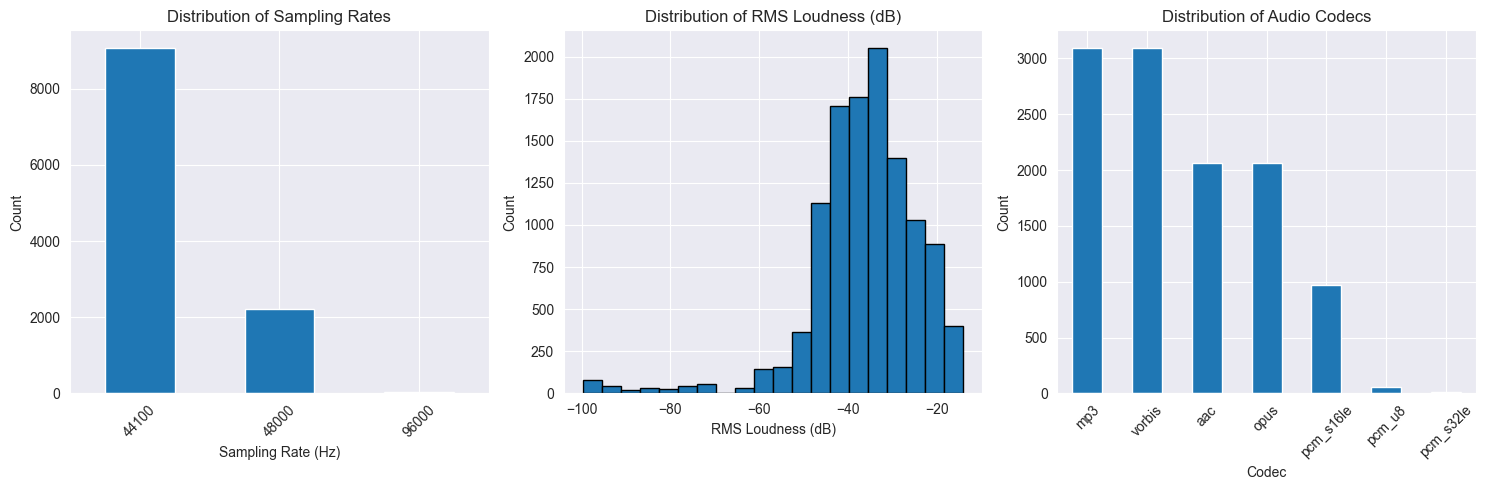

In [4]:
METADATA_FILE = r'C:\Users\Krysia\Desktop\Other\Projekty\Machine Learning\BoarSoundClassifier\Model\SoundData\Metadata_All_Normalized.csv'
analyze_audio_properties(METADATA_FILE)

Skanowanie katalogu: SoundData/RawData w poszukiwaniu plików audio...


Processing audio files: 100%|██████████| 71/71 [01:05<00:00,  1.08it/s]



--- Audio Properties Summary ---
Sampling Rate (Hz):
44100    53
48000    16
96000     2
Name: count, dtype: int64
  Range: 44100 - 96000
------------------------------
Bit Depth (bits per sample):
0      8
8      9
16    51
24     2
32     1
Name: count, dtype: int64
  Range: 0 - 32
------------------------------
Number of Channels:
1     5
2    66
Name: count, dtype: int64
------------------------------
Duration (seconds):
count     71.000000
mean      84.413735
std       92.085012
min        0.432000
25%       16.522000
50%       42.161633
75%      119.737719
max      391.859955
dtype: float64
------------------------------
RMS Loudness (dB, mean across file):
count    71.000000
mean    -37.411934
std       8.085663
min     -62.558163
25%     -42.615631
50%     -37.141693
75%     -33.472288
max     -12.502719
dtype: float64
------------------------------
Detected Audio Codecs:
pcm_s16le    51
pcm_alaw      8
mp3           8
pcm_s24le     2
pcm_s32le     1
pcm_u8        1
Name: coun

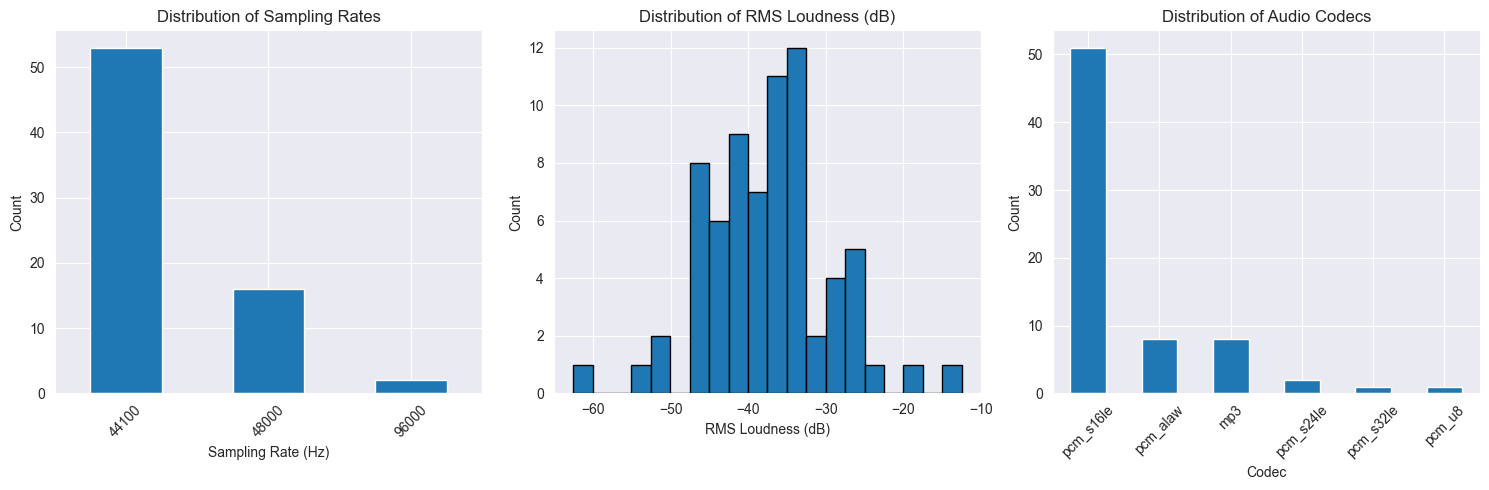

In [8]:
import glob
RAW_DATA_ROOT = 'SoundData/RawData'
SUPPORTED_AUDIO_EXTENSIONS = ('*.wav', '*.flac', '*.mp3', '*.ogg') # Możesz dodać inne, jeśli potrzebujesz

# --- Generowanie listy plików ---
raw_audio_files = []
print(f"Skanowanie katalogu: {RAW_DATA_ROOT} w poszukiwaniu plików audio...")

for ext in SUPPORTED_AUDIO_EXTENSIONS:
    search_pattern = os.path.join(RAW_DATA_ROOT, '**', ext)
    found_files = glob.glob(search_pattern, recursive=True)
    raw_audio_files.extend(found_files)

sample_rates = []
bit_depths = []
num_channels = []
durations = []
rms_values = []
detected_codecs = []

for file_path in tqdm(raw_audio_files, total=len(raw_audio_files), desc="Processing audio files"):
    try:
        info = mediainfo(file_path)

        sample_rates.append(int(info.get('sample_rate', 0)))
        num_channels.append(int(info.get('channels', 0)))

        bit_depth = info.get('bits_per_sample')
        if bit_depth:
            bit_depths.append(int(bit_depth))
        else:
            if 'pcm_s16le' in info.get('codec_long_name', ''):
                bit_depths.append(16)
            elif 'pcm_f32le' in info.get('codec_long_name', ''):
                bit_depths.append(32)
            else:
                bit_depths.append(None)

        durations.append(float(info.get('duration', 0)))

        detected_codecs.append(info.get('codec_name', 'unknown'))

        audio, sr = librosa.load(file_path, sr=None, mono=True)
        rms = librosa.feature.rms(y=audio)
        rms_db = librosa.amplitude_to_db(rms, ref=1.0).mean()
        rms_values.append(rms_db)

    except Exception as e:
        # Use tqdm.write for printing inside the loop to avoid messing up the progress bar
        tqdm.write(f"Error processing {file_path}: {e}")
        continue

sr_series = pd.Series(sample_rates).dropna()
bd_series = pd.Series(bit_depths).dropna()
nc_series = pd.Series(num_channels).dropna()
dur_series = pd.Series(durations).dropna()
rms_series = pd.Series(rms_values).dropna()
codec_series = pd.Series(detected_codecs).dropna()

print("\n--- Audio Properties Summary ---")
print("Sampling Rate (Hz):")
print(sr_series.value_counts().sort_index())
print(f"  Range: {sr_series.min()} - {sr_series.max()}")
print("-" * 30)

print("Bit Depth (bits per sample):")
print(bd_series.value_counts().sort_index())
print(f"  Range: {bd_series.min()} - {bd_series.max()}")
print("-" * 30)

print("Number of Channels:")
print(nc_series.value_counts().sort_index())
print("-" * 30)

print("Duration (seconds):")
print(dur_series.describe())
print("-" * 30)

print("RMS Loudness (dB, mean across file):")
print(rms_series.describe())
print("-" * 30)

print("Detected Audio Codecs:")
print(codec_series.value_counts())
print("-" * 30)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sr_series.value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Sampling Rates')
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.hist(rms_series, bins=20, edgecolor='black')
plt.title('Distribution of RMS Loudness (dB)')
plt.xlabel('RMS Loudness (dB)')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
codec_series.value_counts().plot(kind='bar')
plt.title('Distribution of Audio Codecs')
plt.xlabel('Codec')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
stop

In [ ]:
# Paths to your data
ORIGINAL_AUDIO_DIR = 'SoundData/PreparedData' # Path to your directory with 4s original audio files
ORIGINAL_METADATA_FILE = 'SoundData/Metadata.csv'   # Path to your original metadata CSV file

# Directory for augmented files
AUGMENTED_AUDIO_DIR = 'SoundData/PreparedDataRecompressed'
AUGMENTED_METADATA_FILE = 'SoundData/Metadata_All.csv'

TARGET_FORMATS = {
    "mp3": ["128k", "64k", "32k"],
    "ogg": ["-q:a 3", "-q:a 0", "-q:a 6"],
    "m4a": ["96k", "64k"],
    "opus": ["64k", "32k"]
}

In [ ]:
def convert_and_save_audio(input_path, output_dir, output_filename_base, target_format, quality_setting=None):
    """
    Converts an audio file to a target format with optional quality settings and saves it.

    Args:
        input_path (str): Path to the source audio file.
        output_dir (str): Directory to save the converted file.
        output_filename_base (str): Base name for the output file (without extension),
                                    should already include format and quality suffixes.
        target_format (str): Target audio format (e.g., "mp3", "ogg", "aac", "opus").
        quality_setting (str, optional): Quality setting for the format (e.g., "128k" for mp3, "-q:a 3" for ogg, "64k" for opus).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    try:
        audio_segment = AudioSegment.from_file(input_path)
    except Exception as e:
        print(f"Error loading {input_path} with pydub: {e}")
        return None

    if target_format == 'm4a':
        output_path = os.path.join(output_dir, f"{output_filename_base}.m4a") # Użyj .m4a jako rozszerzenia
    else:
        output_path = os.path.join(output_dir, f"{output_filename_base}.{target_format}")

    try:
        ffmpeg_parameters = []

        if target_format == 'mp3' and quality_setting:
            ffmpeg_parameters.extend(["-b:a", str(quality_setting)])
        elif target_format == 'ogg' and quality_setting:
            ffmpeg_parameters.extend(str(quality_setting).split())
            ffmpeg_parameters.extend(["-codec:a", "libvorbis"]) # Jawne określenie kodeka libvorbis dla OGG
        elif target_format == 'm4a' and quality_setting:
            ffmpeg_parameters.extend(["-b:a", str(quality_setting)])
            ffmpeg_parameters.extend(["-codec:a", "aac"]) # Jawnie ustaw kodek na aac
            ffmpeg_parameters.extend(["-strict", "-2"]) # Ta flaga jest często potrzebna dla enkodera aac w ffmpeg
        elif target_format == 'opus' and quality_setting:
            ffmpeg_parameters.extend(["-b:a", str(quality_setting)])
            ffmpeg_parameters.extend(["-codec:a", "libopus"])

        # Upewnij się, że format przekazany do pydub jest odpowiedni
        # Dla m4a, pydub potrzebuje 'mp4' jako formatu wyjściowego
        if target_format == 'm4a':
            pydub_format = 'mp4'
        else:
            pydub_format = target_format

        audio_segment.export(output_path, format=pydub_format, parameters=ffmpeg_parameters)

        return output_filename_base
    except Exception as e:
        print(f"Error converting and saving {input_path} to {target_format} ({quality_setting}) at {output_path}: {e}")
        if hasattr(e, 'cmd') and hasattr(e, 'output'):
             print(f"FFmpeg command: {e.cmd}")
             print(f"FFmpeg output: {e.output.decode('utf-8', errors='ignore')}") # Dodano errors='ignore'
        return None


In [ ]:
def perform_format_augmentation(original_metadata_path, original_audio_dir, augmented_audio_dir, target_formats, augmented_metadata_path):
    original_df = pd.read_csv(original_metadata_path, sep=';')

    final_metadata_list = []

    print("Rozpoczynam augmentację kompresji...")

    os.makedirs(augmented_audio_dir, exist_ok=True)

    for index, row in original_df.iterrows():
        original_file_name_base = str(row['FileName'])
        original_audio_full_path = os.path.join(original_audio_dir, original_file_name_base + '.wav')

        if os.path.exists(original_audio_full_path):
            original_entry = row.copy()
            original_entry['FilePath'] = original_audio_full_path
            original_entry['OriginalFileName'] = original_file_name_base
            original_entry['FileName'] = original_file_name_base
            final_metadata_list.append(original_entry)
        else:
            print(f"Ostrzeżenie: Oryginalny plik WAV {original_audio_full_path} nie znaleziono. Pomiń.")
            continue

        for target_format, quality_settings in target_formats.items():
            for q_setting in quality_settings:

                safe_q_setting_for_filename = str(q_setting).replace(" ", "").replace(":", "").replace("-", "")
                augmented_file_name_for_conversion = f"{original_file_name_base}_{target_format}_{safe_q_setting_for_filename}"

                converted_filename_base = convert_and_save_audio(
                    original_audio_full_path,
                    augmented_audio_dir,
                    augmented_file_name_for_conversion,
                    target_format,
                    q_setting
                )

                if converted_filename_base:
                    augmented_entry = row.copy()
                    # Specjalna obsługa rozszerzenia dla AAC (teraz m4a)
                    if target_format == 'm4a':
                        augmented_entry['FilePath'] = os.path.join(augmented_audio_dir, f"{converted_filename_base}.m4a")
                    else:
                        augmented_entry['FilePath'] = os.path.join(augmented_audio_dir, f"{converted_filename_base}.{target_format}")
                    augmented_entry['FilePath'] = os.path.join(augmented_audio_dir, f"{converted_filename_base}.{target_format}")
                    augmented_entry['OriginalFileName'] = original_file_name_base
                    augmented_entry['FileName'] = converted_filename_base
                    final_metadata_list.append(augmented_entry)
                else:
                    print(f"Błąd konwersji dla {original_file_name_base} do {target_format} z {q_setting}. Pomiń dodawanie.")

    final_df = pd.DataFrame(final_metadata_list)
    final_df.drop_duplicates(subset=['FilePath'], inplace=True)

    desired_cols = ['FilePath', 'OriginalFileName', 'FileName'] + [col for col in final_df.columns if col not in ['FilePath', 'OriginalFileName', 'FileName']]
    final_df = final_df[desired_cols]

    final_df.to_csv(augmented_metadata_path, index=False, sep=';')
    print(f"\nAugmentacja kompresji zakończona.")
    print(f"Całkowita liczba plików (oryginalnych + zaugmentowanych): {len(final_df)}")
    print(f"Nowe metadane zapisane do: {augmented_metadata_path}")


In [ ]:
perform_format_augmentation(ORIGINAL_METADATA_FILE, ORIGINAL_AUDIO_DIR, AUGMENTED_AUDIO_DIR, TARGET_FORMATS, AUGMENTED_METADATA_FILE)


In [ ]:
import pandas as pd
import os

# --- Konfiguracja ---
input_csv_path = 'SoundData/Metadata_All.csv'
ROOT_DIR_FOR_SOUNDDATA = r'C:\Users\Krysia\Desktop\Other\Projekty\Machine Learning\BoarSoundClassifier\Model'
# Nazwa pliku wyjściowego (opcjonalnie, jeśli chcesz zapisać znormalizowany DF)
output_csv_path = 'SoundData/Metadata_All_Normalized.csv'

# --- Wczytaj dane ---
df = pd.read_csv(input_csv_path, sep=';')

# --- Znormalizuj ścieżkę bazową ---
base_root_dir_norm = os.path.normpath(ROOT_DIR_FOR_SOUNDDATA)

# --- Normalizuj kolumnę 'FilePath' ---
normalized_paths = []
for index, row in df.iterrows():
    relative_path = str(row['FilePath'])
    # Normalizuj separatory (np. / i \) i połącz z bazową ścieżką
    full_path = os.path.join(base_root_dir_norm, os.path.normpath(relative_path))
    # Upewnij się, że ścieżka jest bezwzględna
    absolute_path = os.path.abspath(full_path)
    normalized_paths.append(absolute_path)

df['FilePath'] = normalized_paths

# --- Opcjonalnie: Zapisz znormalizowany DataFrame ---
df.to_csv(output_csv_path, index=False, sep=';')
print(f"Znormalizowane metadane zapisane do: {output_csv_path}")

# --- Podgląd znormalizowanego DataFrame ---
print("\n--- Podgląd znormalizowanego DataFrame (pierwsze 5 wierszy) ---")
print(df.head())

# --- Sprawdzenie kilku znormalizowanych ścieżek ---
print("\n--- Przykładowe znormalizowane ścieżki ---")
for i in range(min(3, len(df))): # Wyświetl pierwsze 3 dla przykładu
    print(df.loc[i, 'FilePath'])

## Mock data to verify

In [ ]:
import pandas as pd
import os
import numpy as np
from scipy.io import wavfile
from pydub import AudioSegment # Upewnij się, że masz to zainstalowane: pip install pydub
# pydub wymaga ffmpeg/libav, więc upewnij się, że masz też zainstalowany ffmpeg.

# --- Ścieżki do mock danych ---
MOCK_BASE_DIR = 'SoundData_Mock'
MOCK_ORIGINAL_AUDIO_DIR = os.path.join(MOCK_BASE_DIR, 'PreparedData')
MOCK_ORIGINAL_METADATA_FILE = os.path.join(MOCK_BASE_DIR, 'Metadata.csv')
MOCK_AUGMENTED_AUDIO_DIR = os.path.join(MOCK_BASE_DIR, 'PreparedDataRecompressed')
MOCK_AUGMENTED_METADATA_FILE = os.path.join(MOCK_BASE_DIR, 'Metadata_Augmented.csv')

def setup_mock_data():
    if os.path.exists(MOCK_BASE_DIR):
        shutil.rmtree(MOCK_BASE_DIR)
        print(f"Usunięto stary katalog mockowy: {MOCK_BASE_DIR}")

    os.makedirs(MOCK_ORIGINAL_AUDIO_DIR, exist_ok=True)
    os.makedirs(MOCK_AUGMENTED_AUDIO_DIR, exist_ok=True)

    # Generowanie mockowych plików WAV
    sample_rate = 22050 # Hz
    duration = 4 # seconds
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    amplitude = 0.5

    frequency1 = 440 # Hz (A4)
    sine_wave1 = amplitude * np.sin(2 * np.pi * frequency1 * t)
    wavfile.write(os.path.join(MOCK_ORIGINAL_AUDIO_DIR, 'mock_audio_01.wav'), sample_rate, (sine_wave1 * 32767).astype(np.int16))

    frequency2 = 880 # Hz (A5)
    sine_wave2 = amplitude * np.sin(2 * np.pi * frequency2 * t)
    wavfile.write(os.path.join(MOCK_ORIGINAL_AUDIO_DIR, 'mock_audio_02.wav'), sample_rate, (sine_wave2 * 32767).astype(np.int16))

    print(f"Utworzono mockowe pliki audio w: {MOCK_ORIGINAL_AUDIO_DIR}")

    # Tworzenie mockowego pliku metadanych
    mock_metadata = pd.DataFrame({
        'FileName': ['mock_audio_01', 'mock_audio_02'],
        'Label': [1, 0],
        'BoarSounds': ['', ''],
        'BackgroundNoise': ['', ''],
        'Source': ['MockGen', 'MockGen'],
        'Quality': [1, 1],
        'SamplingRate': [sample_rate, sample_rate]
    })

    mock_metadata.to_csv(MOCK_ORIGINAL_METADATA_FILE, index=False, sep=';')
    print(f"Utworzono mockowy plik metadanych w: {MOCK_ORIGINAL_METADATA_FILE}")


In [ ]:
import os
from pydub import AudioSegment

def convert_and_save_audio(input_path, output_dir, output_filename_base, target_format, quality_setting=None):
    """
    Converts an audio file to a target format with optional quality settings and saves it.

    Args:
        input_path (str): Path to the source audio file.
        output_dir (str): Directory to save the converted file.
        output_filename_base (str): Base name for the output file (without extension),
                                    should already include format and quality suffixes.
        target_format (str): Target audio format (e.g., "mp3", "ogg", "aac", "opus").
        quality_setting (str, optional): Quality setting for the format (e.g., "128k" for mp3, "-q:a 3" for ogg, "64k" for opus).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    try:
        audio_segment = AudioSegment.from_file(input_path)
    except Exception as e:
        print(f"Error loading {input_path} with pydub: {e}")
        return None

    if target_format == 'm4a':
        output_path = os.path.join(output_dir, f"{output_filename_base}.m4a") # Użyj .m4a jako rozszerzenia
    else:
        output_path = os.path.join(output_dir, f"{output_filename_base}.{target_format}")


    try:
        ffmpeg_parameters = []

        if target_format == 'mp3' and quality_setting:
            ffmpeg_parameters.extend(["-b:a", str(quality_setting)])
        elif target_format == 'ogg' and quality_setting:
            ffmpeg_parameters.extend(str(quality_setting).split())
            ffmpeg_parameters.extend(["-codec:a", "libvorbis"]) # Jawne określenie kodeka libvorbis dla OGG
        elif target_format == 'm4a' and quality_setting:
            ffmpeg_parameters.extend(["-b:a", str(quality_setting)])
            ffmpeg_parameters.extend(["-codec:a", "aac"]) # Jawnie ustaw kodek na aac
            ffmpeg_parameters.extend(["-strict", "-2"]) # Ta flaga jest często potrzebna dla enkodera aac w ffmpeg
        elif target_format == 'opus' and quality_setting:
            ffmpeg_parameters.extend(["-b:a", str(quality_setting)])
            ffmpeg_parameters.extend(["-codec:a", "libopus"])

        # Upewnij się, że format przekazany do pydub jest odpowiedni
        # Dla m4a, pydub potrzebuje 'mp4' jako formatu wyjściowego
        if target_format == 'm4a':
            pydub_format = 'mp4'
        else:
            pydub_format = target_format

        audio_segment.export(output_path, format=pydub_format, parameters=ffmpeg_parameters)

        return output_filename_base
    except Exception as e:
        print(f"Error converting and saving {input_path} to {target_format} ({quality_setting}) at {output_path}: {e}")
        if hasattr(e, 'cmd') and hasattr(e, 'output'):
             print(f"FFmpeg command: {e.cmd}")
             print(f"FFmpeg output: {e.output.decode('utf-8', errors='ignore')}") # Dodano errors='ignore'
        return None



In [ ]:
import pandas as pd
import os
# from pydub import AudioSegment # Upewnij się, że AudioSegment jest zdefiniowane/zaimportowane

# Upewnij się, że convert_and_save_audio i TARGET_FORMATS są zaktualizowane zgodnie z powyższymi sugestiami.

def perform_format_augmentation(original_metadata_path, original_audio_dir, augmented_audio_dir, target_formats, augmented_metadata_path):
    original_df = pd.read_csv(original_metadata_path, sep=';')

    final_metadata_list = []

    print("Rozpoczynam augmentację kompresji...")

    os.makedirs(augmented_audio_dir, exist_ok=True)

    for index, row in original_df.iterrows():
        original_file_name_base = str(row['FileName'])
        original_audio_full_path = os.path.join(original_audio_dir, original_file_name_base + '.wav')

        if os.path.exists(original_audio_full_path):
            original_entry = row.copy()
            original_entry['FilePath'] = original_audio_full_path
            original_entry['OriginalFileName'] = original_file_name_base
            original_entry['FileName'] = original_file_name_base
            final_metadata_list.append(original_entry)
        else:
            print(f"Ostrzeżenie: Oryginalny plik WAV {original_audio_full_path} nie znaleziono. Pomiń.")
            continue

        for target_format, quality_settings in target_formats.items():
            for q_setting in quality_settings:

                safe_q_setting_for_filename = str(q_setting).replace(" ", "").replace(":", "").replace("-", "")
                augmented_file_name_for_conversion = f"{original_file_name_base}_{target_format}_{safe_q_setting_for_filename}"

                converted_filename_base = convert_and_save_audio(
                    original_audio_full_path,
                    augmented_audio_dir,
                    augmented_file_name_for_conversion,
                    target_format,
                    q_setting
                )

                if converted_filename_base:
                    augmented_entry = row.copy()
                    # Specjalna obsługa rozszerzenia dla AAC (teraz m4a)
                    if target_format == 'm4a':
                        augmented_entry['FilePath'] = os.path.join(augmented_audio_dir, f"{converted_filename_base}.m4a")
                    else:
                        augmented_entry['FilePath'] = os.path.join(augmented_audio_dir, f"{converted_filename_base}.{target_format}")
                    augmented_entry['FilePath'] = os.path.join(augmented_audio_dir, f"{converted_filename_base}.{target_format}")
                    augmented_entry['OriginalFileName'] = original_file_name_base
                    augmented_entry['FileName'] = converted_filename_base
                    final_metadata_list.append(augmented_entry)
                else:
                    print(f"Błąd konwersji dla {original_file_name_base} do {target_format} z {q_setting}. Pomiń dodawanie.")

    final_df = pd.DataFrame(final_metadata_list)
    final_df.drop_duplicates(subset=['FilePath'], inplace=True)

    desired_cols = ['FilePath', 'OriginalFileName', 'FileName'] + [col for col in final_df.columns if col not in ['FilePath', 'OriginalFileName', 'FileName']]
    final_df = final_df[desired_cols]

    final_df.to_csv(augmented_metadata_path, index=False, sep=';')
    print(f"\nAugmentacja kompresji zakończona.")
    print(f"Całkowita liczba plików (oryginalnych + zaugmentowanych): {len(final_df)}")
    print(f"Nowe metadane zapisane do: {augmented_metadata_path}")


In [ ]:
setup_mock_data()

# 2. Zdefiniuj TARGET_FORMATS_MOCK z nowymi formatami
TARGET_FORMATS_MOCK = {
    "mp3": ["128k"],
    "ogg": ["-q:a 3"], # OGG z jakością zmienną
    "m4a": ["96k"],    # AAC z bitrate'em
    "opus": ["64k"]    # Opus z bitrate'em
}

# 3. Uruchom augmentację
perform_format_augmentation(
    MOCK_ORIGINAL_METADATA_FILE,
    MOCK_ORIGINAL_AUDIO_DIR,
    MOCK_AUGMENTED_AUDIO_DIR,
    TARGET_FORMATS_MOCK,
    MOCK_AUGMENTED_METADATA_FILE
)

# 4. Weryfikacja wyników
print("\n--- Weryfikacja wygenerowanych plików i metadanych ---")
print(f"Zawartość katalogu oryginalnego: {os.listdir(MOCK_ORIGINAL_AUDIO_DIR)}")
print(f"Zawartość katalogu augmentowanego: {os.listdir(MOCK_AUGMENTED_AUDIO_DIR)}")

try:
    augmented_df_check = pd.read_csv(MOCK_AUGMENTED_METADATA_FILE, sep=';')
    print("\nZawartość wygenerowanego pliku metadanych (Metadata_Augmented.csv):")
    print(augmented_df_check.head(10))
    print(f"\nCałkowita liczba wierszy w metadanych: {len(augmented_df_check)}")

    print("\nSprawdzanie istnienia i ładowania plików:")
    for idx, row in augmented_df_check.sample(min(8, len(augmented_df_check))).iterrows(): # Losowe próbki, max 8
        file_path = row['FilePath']
        print(f"  Sprawdzanie pliku: {file_path}")
        if os.path.exists(file_path):
            try:
                AudioSegment.from_file(file_path)
                print("  Pydub może załadować plik pomyślnie.")
            except Exception as e:
                print(f"  Błąd pydub przy ładowaniu pliku: {e}")
        else:
            print(f"  BŁĄD: Plik nie istnieje: {file_path}")

except Exception as e:
    print(f"Błąd podczas weryfikacji pliku metadanych: {e}")

